In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from collections import Counter

DATA INGESTION in pipeline

In [2]:
#Dataset
from ucimlrepo import fetch_ucirepo 
cancer_data = fetch_ucirepo(id=15) # fetch dataset 
# data (as pandas dataframes) 
X = cancer_data.data.features 
y = cancer_data.data.targets
ids= cancer_data.data.ids

# Check the shape of data
print(f"Features shape: {X.shape}") #Features shape: (699, 9)
print(f"Target shape: {y.shape}") #Target shape: (699, 1)
print(f"IDs shape: {ids.shape}") #IDs shape: (699, 1)
# Look at data
print(X.head())

Features shape: (699, 9)
Target shape: (699, 1)
IDs shape: (699, 1)
   Clump_thickness  Uniformity_of_cell_size  Uniformity_of_cell_shape  \
0                5                        1                         1   
1                5                        4                         4   
2                3                        1                         1   
3                6                        8                         8   
4                4                        1                         1   

   Marginal_adhesion  Single_epithelial_cell_size  Bare_nuclei  \
0                  1                            2          1.0   
1                  5                            7         10.0   
2                  1                            2          2.0   
3                  1                            3          4.0   
4                  3                            2          1.0   

   Bland_chromatin  Normal_nucleoli  Mitoses  
0                3                1        1  
1 

In [3]:
print(y.head())
print(ids.head())
print (y.value_counts()) # Check target distribution: 458 benign (2), 241 malignant (4)
print(X.isnull().sum())# Check for missing values, 16 missing values in 'Bare_nuclei' column
print("ID CHECK")
print(ids.isnull().sum())# Check for missing values in ids column

   Class
0      2
1      2
2      2
3      2
4      2
   Sample_code_number
0             1000025
1             1002945
2             1015425
3             1016277
4             1017023
Class
2        458
4        241
Name: count, dtype: int64
Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
dtype: int64
ID CHECK
Sample_code_number    0
dtype: int64


In [4]:
# Basic statistics
print("DATA STATS")
print(X.info()) #all int, bare_nuclei float (683 entries non-null)
print(X.describe()) # count, mean, std, min, 25%, 50%, 75%, max for each feature

DATA STATS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
dtypes: float64(1), int64(8)
memory usage: 49.3 KB
None
       Clump_thickness  Uniformity_of_cell_size  Uniformity_of_cell_shape  \
count       699.000000               699.000000                699.000000   
mean          4.417740               

In [5]:
print(y.describe())

            Class
count  699.000000
mean     2.689557
std      0.951273
min      2.000000
25%      2.000000
50%      2.000000
75%      4.000000
max      4.000000


Data Cleaning - Handle missing values in 'Bare_nuclei' column

In [6]:
print((X.isnull().sum()/ len(X))) #2.289% missing values in 'Bare_nuclei' column
print(X['Bare_nuclei'].value_counts()) # Check unique values in 'Bare_nuclei' column: 1.0 402, 10.0 132

# Missing values
X_null=X.fillna(X.mean()) # Fill missing values with mean of the column, mean since it's numerical
X_null['Bare_nuclei'] = X_null['Bare_nuclei'].astype(int) # Convert 'Bare_nuclei' to integer type

#Duplicate rows
duplicate_check=X_null.duplicated().any() # Check for duplicate rows
print(f"Are there duplicate rows? {duplicate_check}")
print(f"Shape before cleaning: {X_null.shape}") # Shape before cleaning (699, 9)
print(f"Number of duplicate rows: {X_null.duplicated().sum()}") # Number of duplicate rows, 237 
dup=X_null[X_null.duplicated(keep=False)]  # Display duplicate rows

X_clean=X_null.drop_duplicates() # Drop duplicate rows if any
print(f"New shape after cleaning: {X_clean.shape}") # New shape after cleaning (462, 9)
y_clean=y.loc[X_clean.index] # Align target variable with cleaned features
ids_clean=ids.loc[X_clean.index] # Align ids with cleaned features
print(f"Target shape after cleaning: {y_clean.shape}") # Target shape after cleaning
print(f"IDs shape after cleaning: {ids_clean.shape}") # IDs shape after cleaning

Clump_thickness                0.00000
Uniformity_of_cell_size        0.00000
Uniformity_of_cell_shape       0.00000
Marginal_adhesion              0.00000
Single_epithelial_cell_size    0.00000
Bare_nuclei                    0.02289
Bland_chromatin                0.00000
Normal_nucleoli                0.00000
Mitoses                        0.00000
dtype: float64
Bare_nuclei
1.0     402
10.0    132
2.0      30
5.0      30
3.0      28
8.0      21
4.0      19
9.0       9
7.0       8
6.0       4
Name: count, dtype: int64
Are there duplicate rows? True
Shape before cleaning: (699, 9)
Number of duplicate rows: 237
New shape after cleaning: (462, 9)
Target shape after cleaning: (462, 1)
IDs shape after cleaning: (462, 1)


CODE CHECK

In [8]:
print("DATA CLEANING CHECK")
print(X_clean.shape)
print(X_clean.columns)
print(X_clean.dtypes)
print(X_clean.isnull().sum())
print(y_clean.value_counts())

DATA CLEANING CHECK
(462, 9)
Index(['Clump_thickness', 'Uniformity_of_cell_size',
       'Uniformity_of_cell_shape', 'Marginal_adhesion',
       'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin',
       'Normal_nucleoli', 'Mitoses'],
      dtype='object')
Clump_thickness                int64
Uniformity_of_cell_size        int64
Uniformity_of_cell_shape       int64
Marginal_adhesion              int64
Single_epithelial_cell_size    int64
Bare_nuclei                    int64
Bland_chromatin                int64
Normal_nucleoli                int64
Mitoses                        int64
dtype: object
Clump_thickness                0
Uniformity_of_cell_size        0
Uniformity_of_cell_shape       0
Marginal_adhesion              0
Single_epithelial_cell_size    0
Bare_nuclei                    0
Bland_chromatin                0
Normal_nucleoli                0
Mitoses                        0
dtype: int64
Class
4        238
2        224
Name: count, dtype: int64


In [9]:
# EDA
print(X_clean.describe()) # Basic statistics after cleaning
print(y_clean.describe()) # Target stats after cleaning

       Clump_thickness  Uniformity_of_cell_size  Uniformity_of_cell_shape  \
count       462.000000               462.000000                462.000000   
mean          5.329004                 4.181818                  4.246753   
std           2.874826                 3.239777                  3.121499   
min           1.000000                 1.000000                  1.000000   
25%           3.000000                 1.000000                  1.000000   
50%           5.000000                 3.000000                  3.000000   
75%           8.000000                 7.000000                  7.000000   
max          10.000000                10.000000                 10.000000   

       Marginal_adhesion  Single_epithelial_cell_size  Bare_nuclei  \
count         462.000000                   462.000000   462.000000   
mean            3.696970                     3.844156     4.755411   
std             3.153202                     2.448063     3.837073   
min             1.000000  

keep outliers

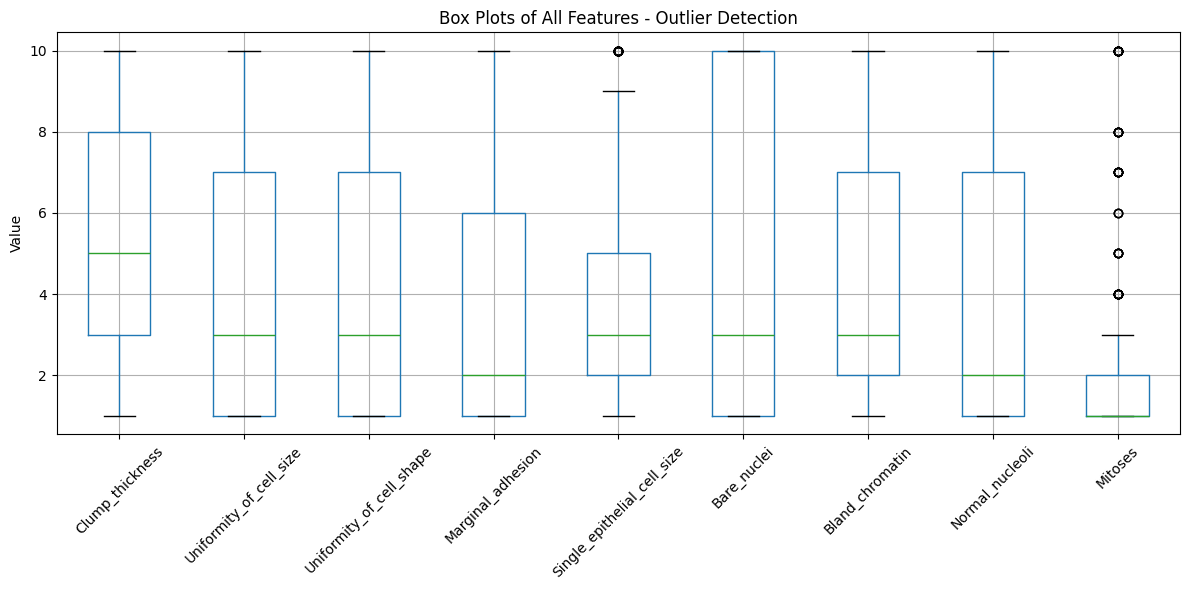

In [10]:
#Box plots for all features to visualize outliers
plt.figure(figsize=(12, 6))
X_clean.boxplot()
plt.title('Box Plots of All Features - Outlier Detection')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.tight_layout()
plt.show() 

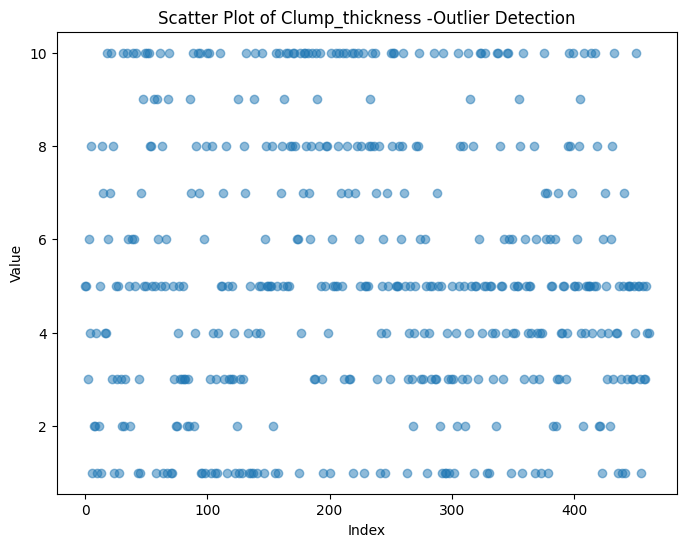

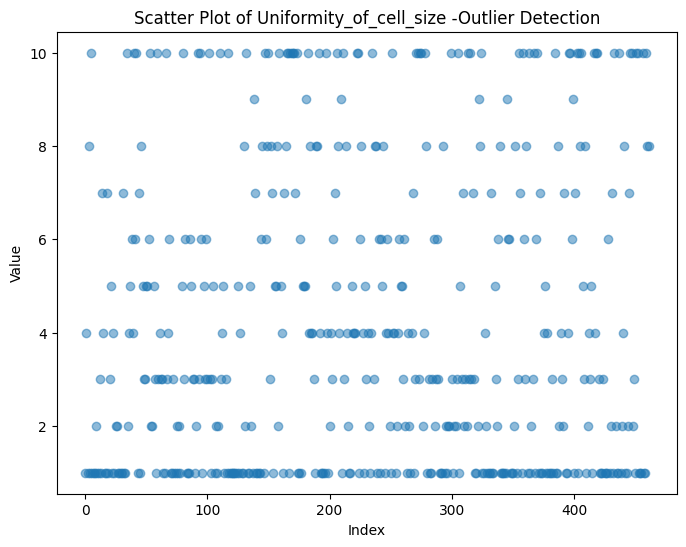

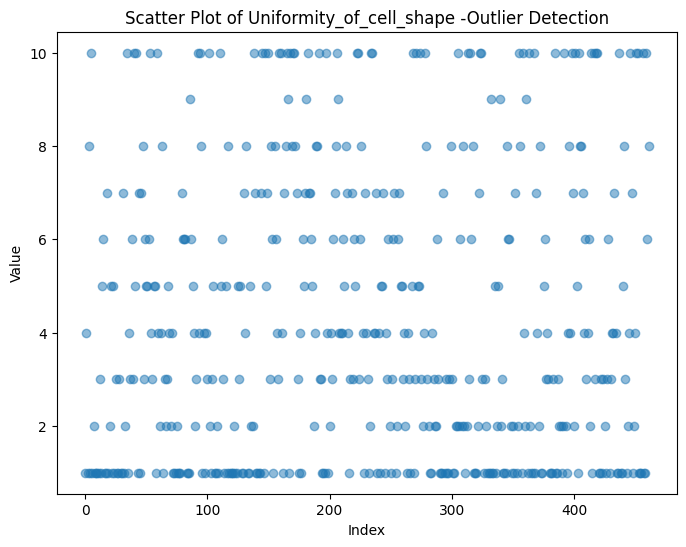

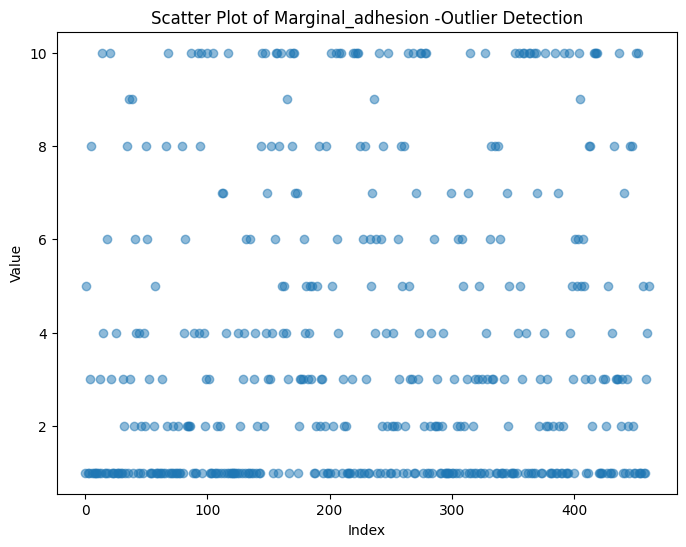

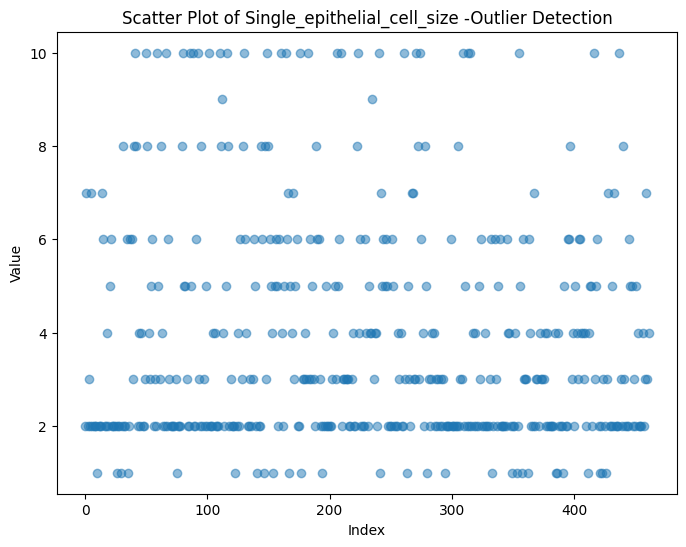

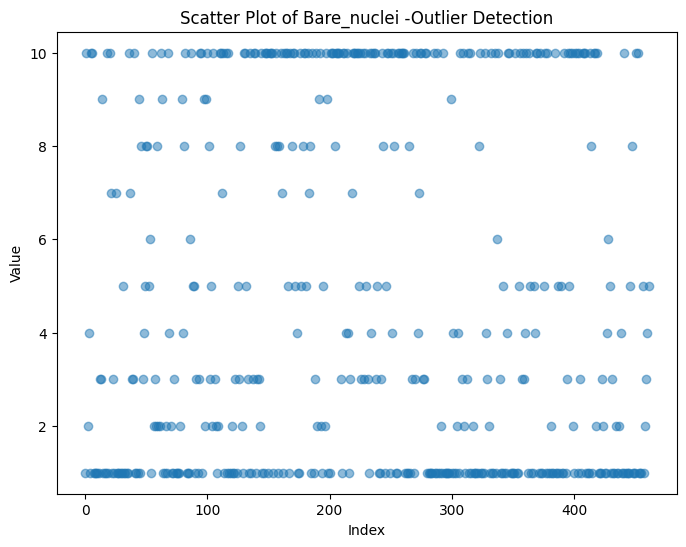

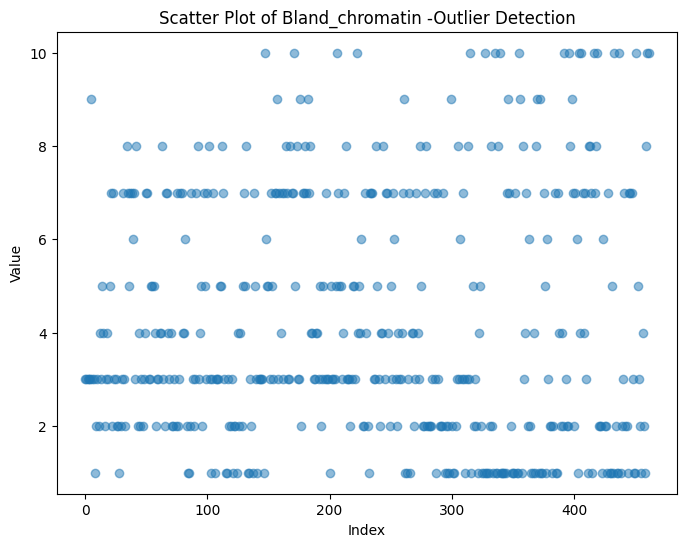

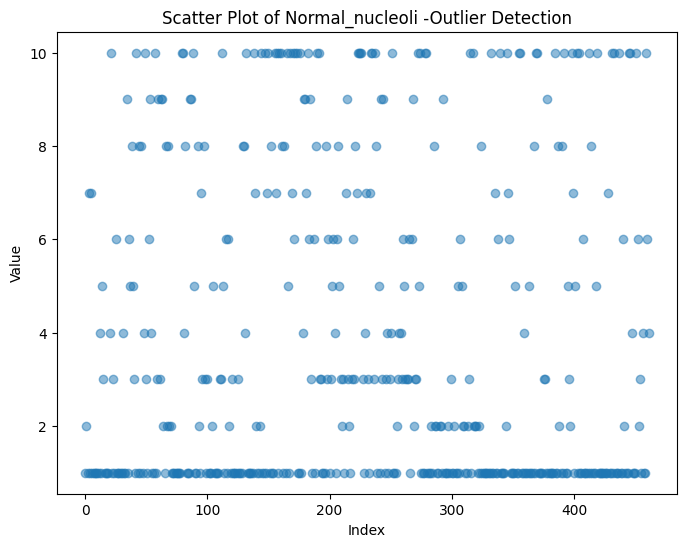

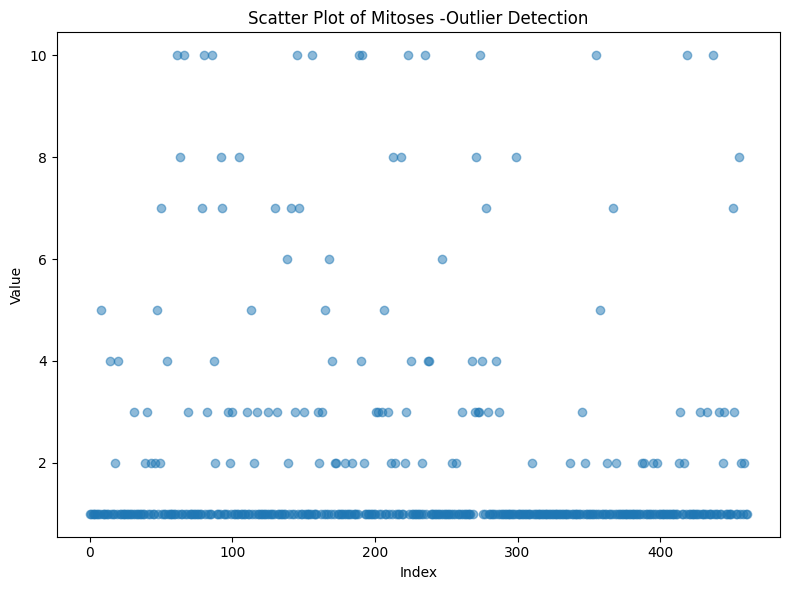

In [11]:
# Regression= scatter plot
for column in X_clean.columns:
    fig, ax= plt.subplots(figsize=(8,6))
    ax.scatter(range(len(X_clean)), X_clean[column], alpha=0.5)
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title(f'Scatter Plot of {column} -Outlier Detection')

plt.tight_layout()
plt.show() #out of loop to see all graphs together


Class
4        51.515152
2        48.484848
Name: proportion, dtype: float64


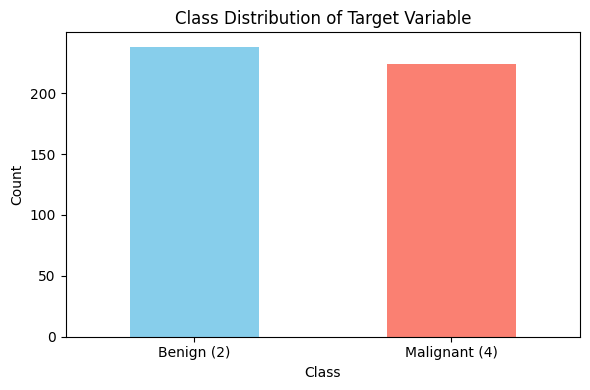

In [12]:
# Class Distribution
print(y_clean.value_counts(normalize=True)*100) # Class distribution percentages: 2- 48.485%, 4- 51.515%
plt.figure(figsize=(6,4))
y_clean.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution of Target Variable') 
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=[0,1], labels=['Benign (2)', 'Malignant (4)'], rotation=0)
plt.tight_layout()
plt.show()

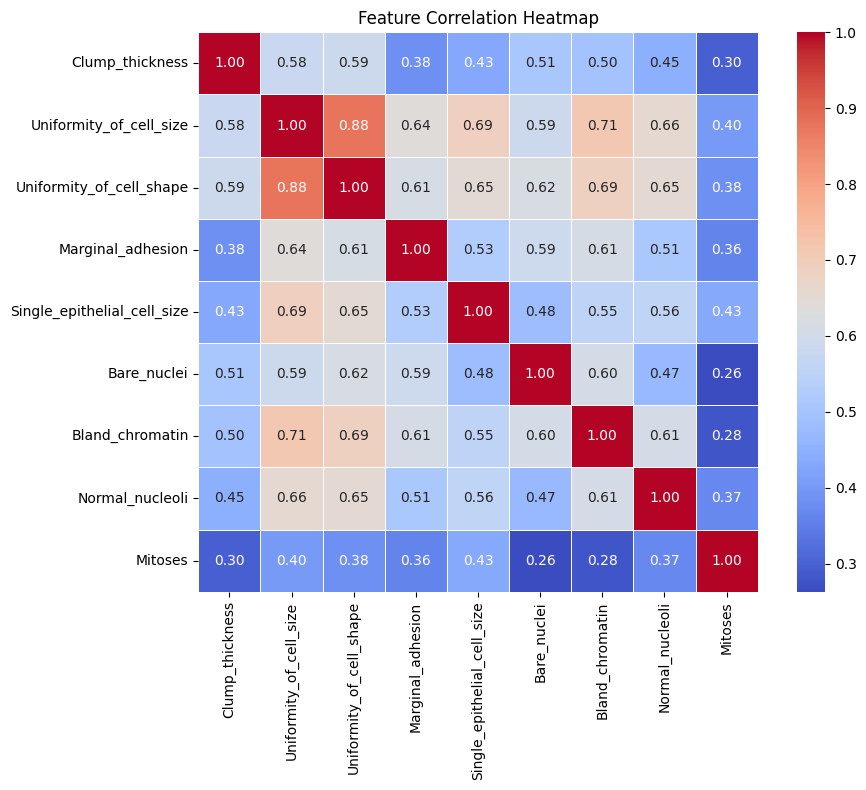

In [13]:
# Correlation matrix to see relationships between features
plt.figure(figsize=(10,8))
correlation_matrix = X_clean.corr() #correlation matrix
#print(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linecolor='white', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

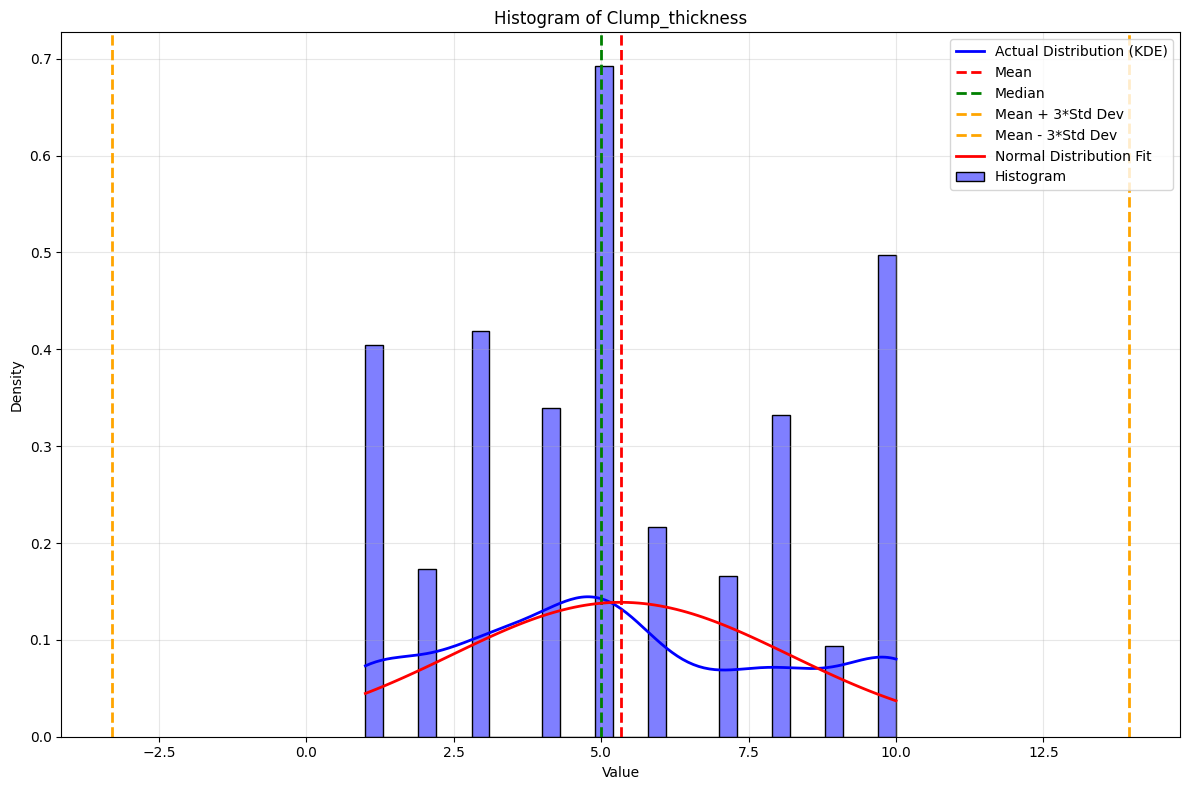

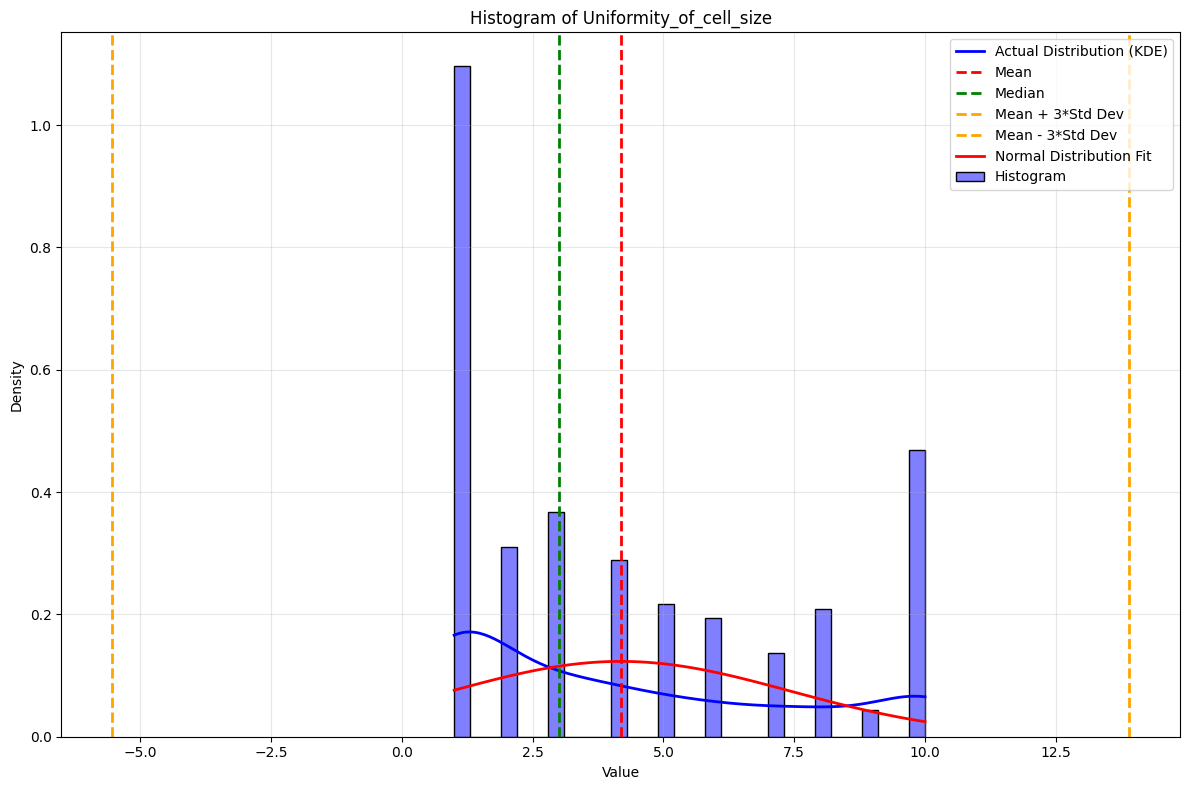

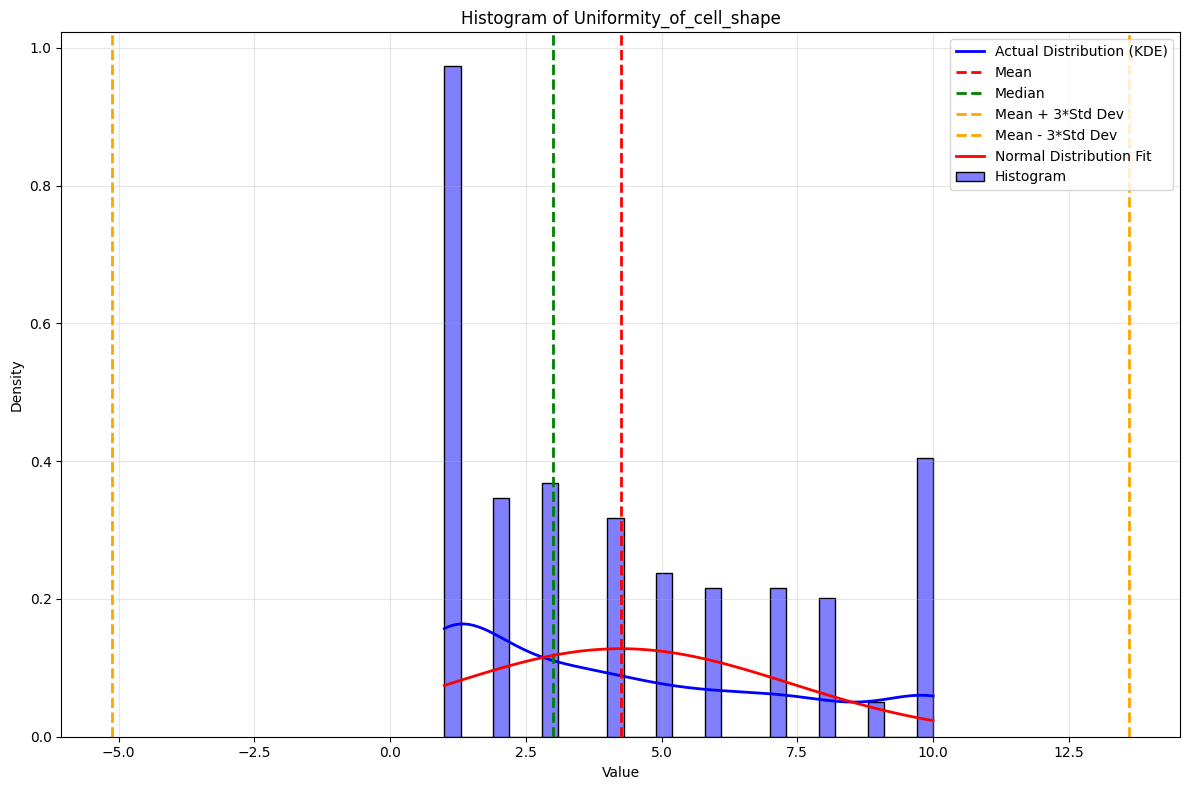

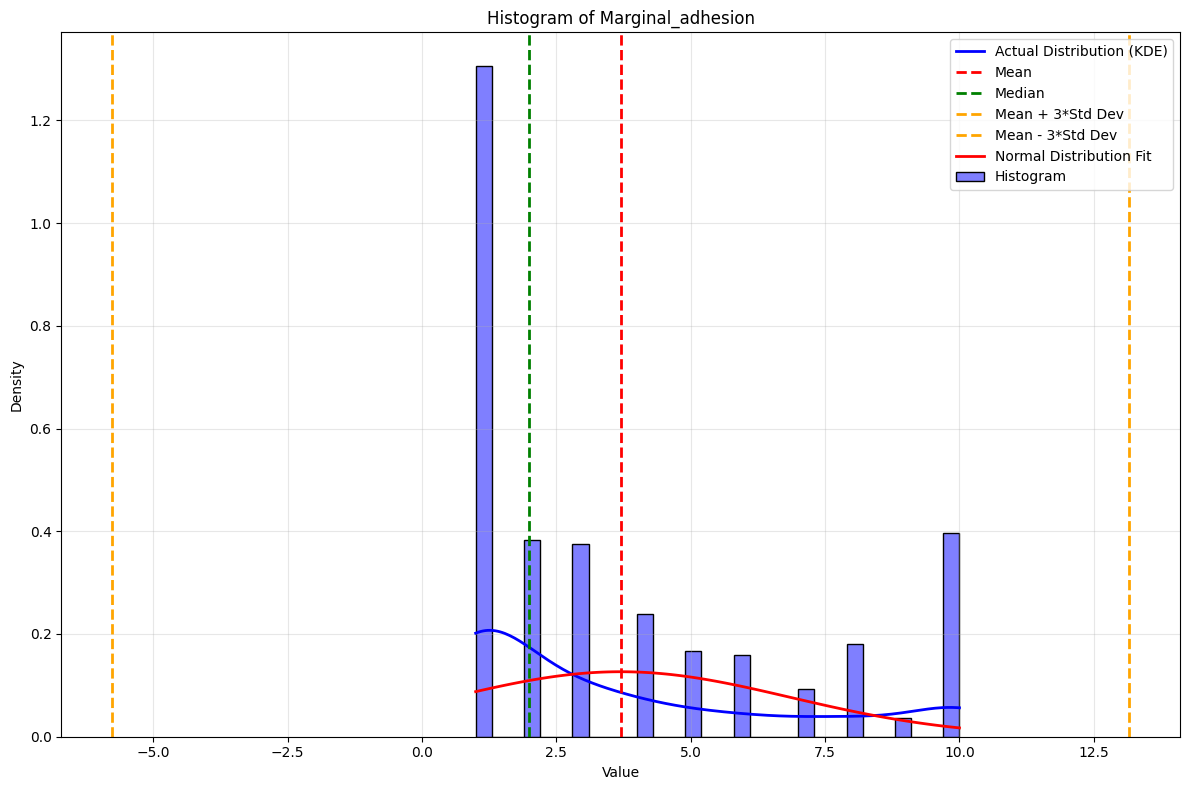

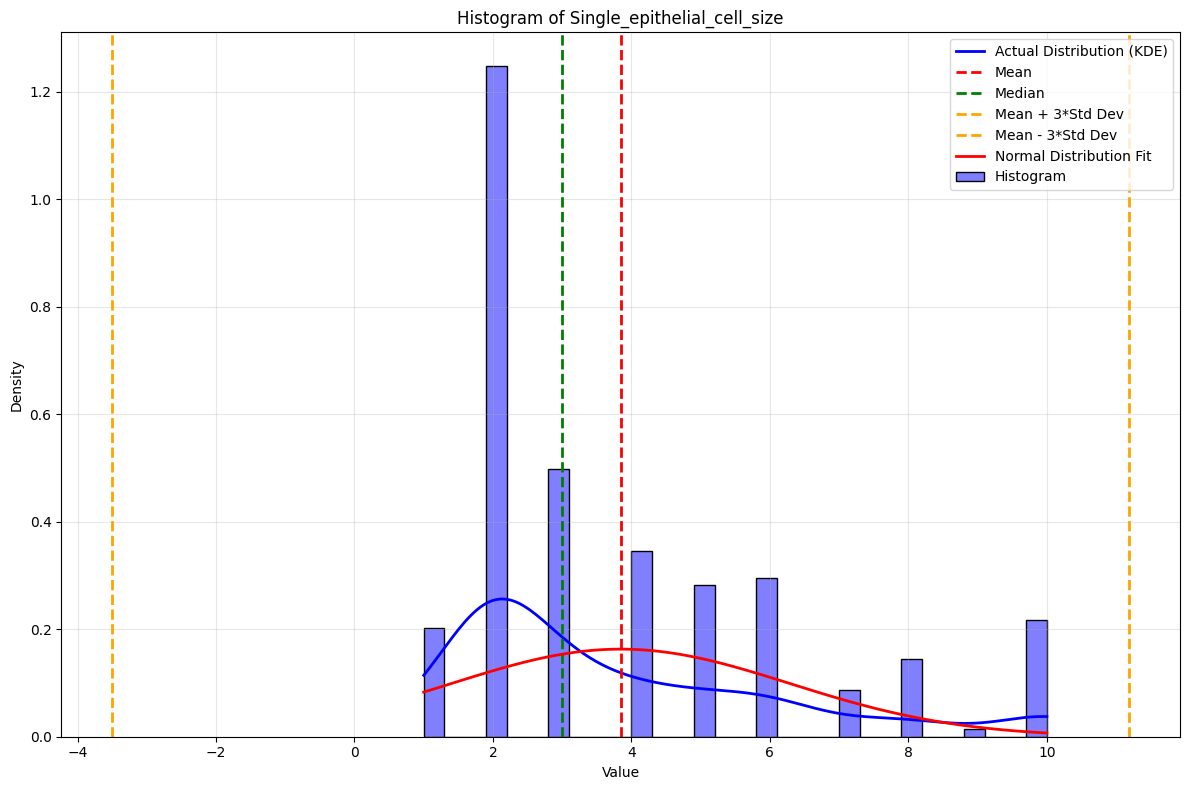

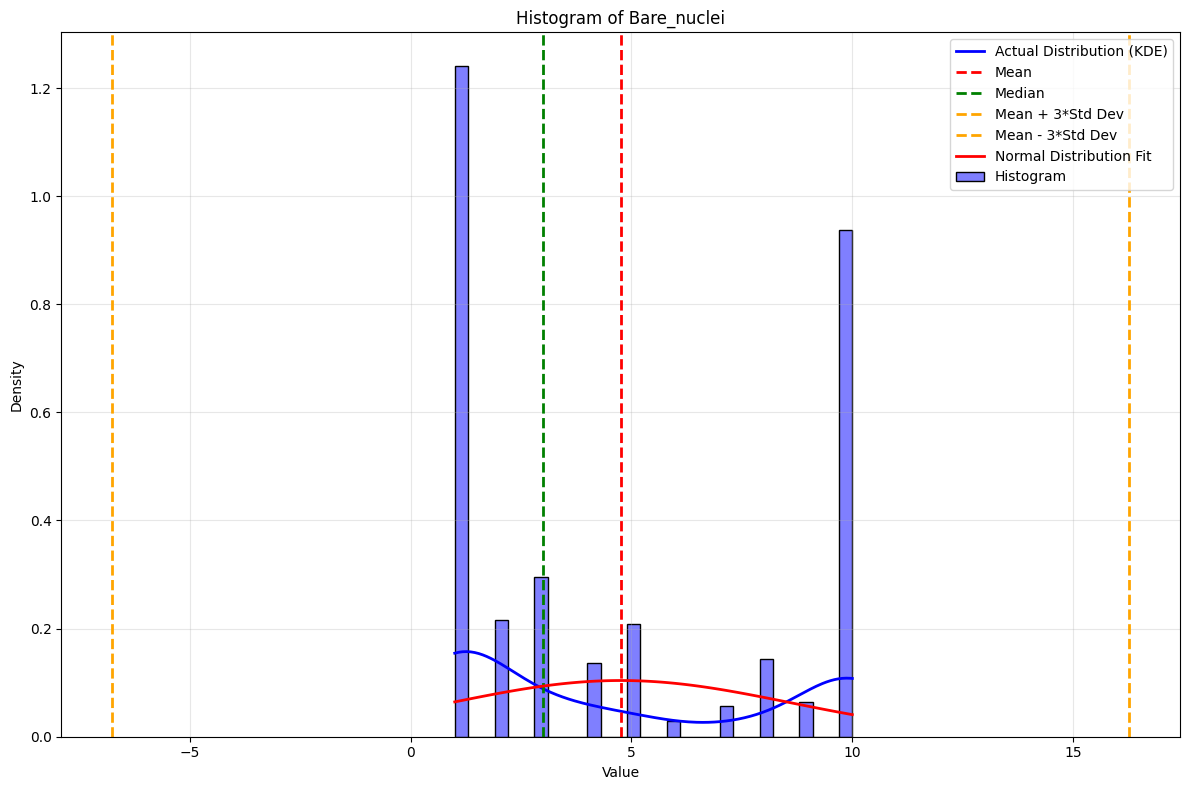

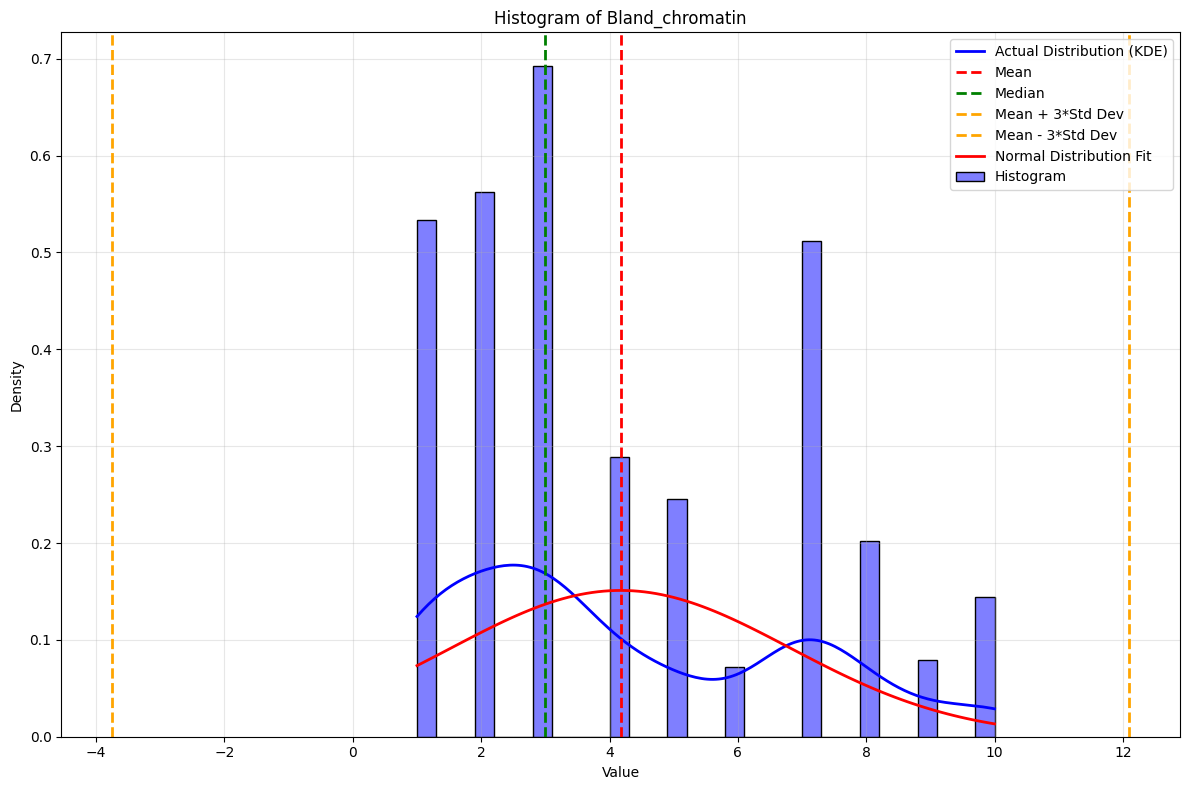

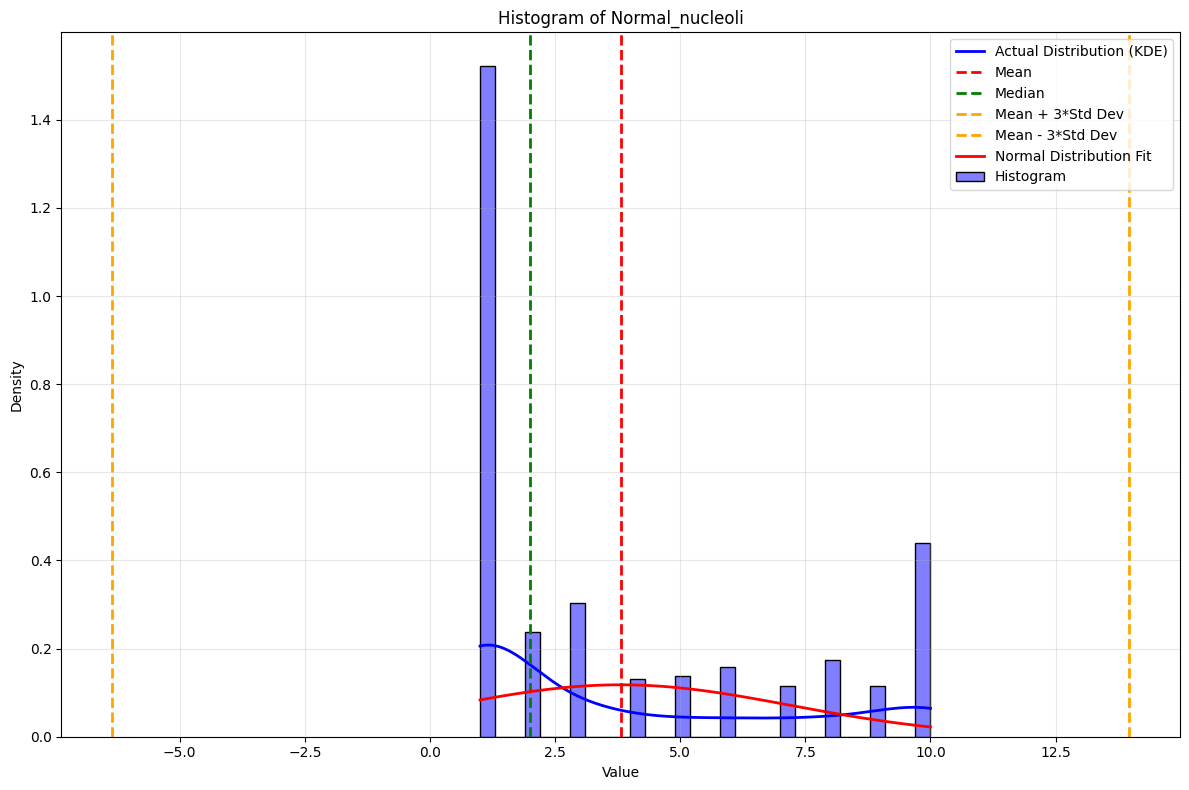

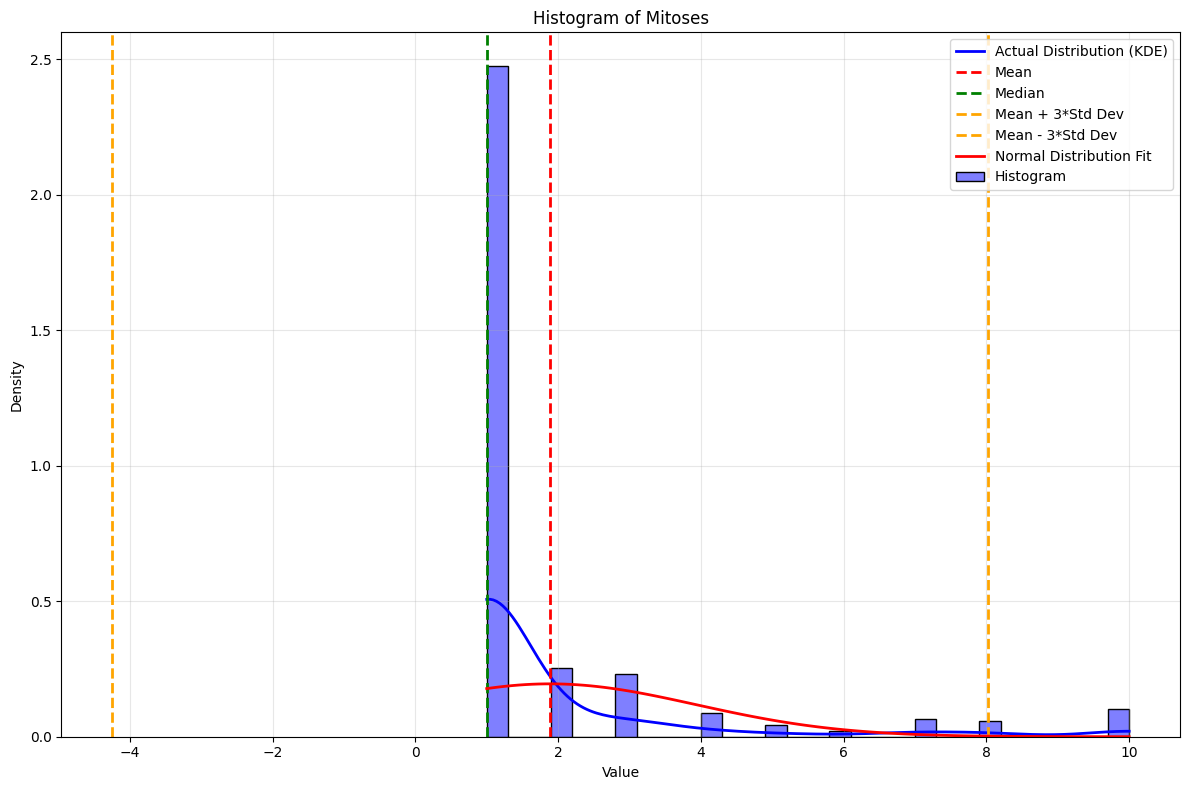

In [14]:
#Histogram for all features to find outliers
for column in X_clean.columns:
    fig, ax= plt.subplots(figsize=(12, 8))
    mean = X_clean[column].mean()
    std = X_clean[column].std()
    median= X_clean[column].median()
    x= np.linspace(X_clean[column].min(), X_clean[column].max(), 100)  

    sns.histplot(X_clean[column], bins=30, kde=True, color='blue', edgecolor='black', ax=ax, stat= 'density', label='Histogram', line_kws={'color': 'purple', 'lw': 2, 'label': 'Actual Distribution (KDE)'})
    ax.axvline(mean, color='red', linestyle='dashed', linewidth=2, label='Mean')
    ax.axvline(median, color='green', linestyle='dashed', linewidth=2, label='Median')
    ax.axvline(mean + 3*std, color='orange', linestyle='dashed', linewidth=2, label='Mean + 3*Std Dev')
    ax.axvline(mean - 3*std, color='orange', linestyle='dashed', linewidth=2, label='Mean - 3*Std Dev')    

    normal_curve= stats.norm.pdf(x, mean, std)
    ax.plot(x, normal_curve, color='red', linewidth=2, label='Normal Distribution Fit')
    ax.set_title(f'Histogram of {column}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

plt.show()

ENCODING

In [15]:
# ENCODING
y_encoded= y_clean.replace({2:0, 4:1}) # Encode target variable: 2 -> 0 (benign), 4 -> 1 (malignant)
#y_singleCol= y_encoded.values.ravel()) # Check encoded target values
print("Unique values",y_encoded.nunique()) # Check unique values in encoded target: [0, 1]
print("Value count",y_encoded.value_counts()) # Check encoded target distribution: 0- 224, 1- 238
print("Percentages",y_encoded.value_counts(normalize=True)*100) # Percentages: 0- 48.485%, 1- 51.515%

Unique values Class    2
dtype: int64
Value count Class
1        238
0        224
Name: count, dtype: int64
Percentages Class
1        51.515152
0        48.484848
Name: proportion, dtype: float64


TRAIN-TEST SPLIT

References:
https://www.datacamp.com/tutorial/decision-tree-classification-python 
https://medium.com/@enozeren/building-a-decision-tree-from-scratch-324b9a5ed836 from pg194

In [16]:
#Plan:class separation, shuffle in each class, split into class, merge, shuffle merged
np.random.seed(42)

# Separate classes
benign_indices = y_encoded[y_encoded == 0].index.tolist()
malignant_indices = y_encoded[y_encoded == 1].index.tolist()

# Shuffle indices within each class
np.random.shuffle(benign_indices)
np.random.shuffle(malignant_indices)

# Split indices into train and test sets (80-20 split)
test_size=0.2 #80/20 but could try 70/30
benign_split = int(len(benign_indices)*(1 - test_size))
print("Number of indices benign", benign_split)
malignant_split = int(len(malignant_indices)*(1 - test_size))
print("Number of malignant", malignant_split)

benign_train_indices = benign_indices[:benign_split] #80% for training
benign_test_indices = benign_indices[benign_split:] #20% for testing

malignant_train_indices = malignant_indices[:malignant_split]
malignant_test_indices = malignant_indices[malignant_split:]


#Merge train and test indices
train_set= benign_train_indices + malignant_train_indices
test_set= benign_test_indices + malignant_test_indices

# Shuffle merged train and test sets
np.random.shuffle(train_set)
np.random.shuffle(test_set)

X_train= X_clean.loc[train_set]
y_train= y_encoded.loc[train_set]
X_test= X_clean.loc[test_set]
y_test= y_encoded.loc[test_set]
print("Train shape:", X_train.shape, y_train.shape) #(738,9) (738,1)
print("Test shape:", X_test.shape, y_test.shape) #(186,9) (186,1)

Number of indices benign 369
Number of malignant 369
Train shape: (738, 9) (738, 1)
Test shape: (186, 9) (186, 1)


In [17]:
#CODE CHECK
print("X set", X_train.shape, X_test.shape)
print("Y set", y_train.shape, y_test.shape)
print("Training distribution",y_train.value_counts(), y_train.value_counts(normalize=True)*100)
print("Testing distribution",y_test.value_counts(), y_test.value_counts(normalize=True)*100)


X set (738, 9) (186, 9)
Y set (738, 1) (186, 1)
Training distribution Class
1        370
0        368
Name: count, dtype: int64 Class
1        50.135501
0        49.864499
Name: proportion, dtype: float64
Testing distribution Class
1        106
0         80
Name: count, dtype: int64 Class
1        56.989247
0        43.010753
Name: proportion, dtype: float64


In [18]:
# SCALING
train_mean= X_train.mean()
train_std= X_train.std()
print("Train mean", train_mean)
print("Train std", train_std)

X_train_scaled= (X_train - train_mean)/ train_std
X_test_scaled= (X_test - train_mean)/ train_std # standarised using train mean and std


Train mean Clump_thickness                5.279133
Uniformity_of_cell_size        4.100271
Uniformity_of_cell_shape       4.163957
Marginal_adhesion              3.653117
Single_epithelial_cell_size    3.794038
Bare_nuclei                    4.695122
Bland_chromatin                4.147696
Normal_nucleoli                3.726287
Mitoses                        1.890244
dtype: float64
Train std Clump_thickness                2.829985
Uniformity_of_cell_size        3.236197
Uniformity_of_cell_shape       3.121502
Marginal_adhesion              3.153082
Single_epithelial_cell_size    2.445802
Bare_nuclei                    3.844043
Bland_chromatin                2.648801
Normal_nucleoli                3.351565
Mitoses                        2.039006
dtype: float64


In [19]:
print("Scaled training set", X_train_scaled.mean())
print("Scaled testing set", X_test_scaled.mean())
print("Scaled training set std", X_train_scaled.std())  #all std=1
print("Scaled testing set std", X_test_scaled.std())  #close to 1
print("Shape", X_train_scaled.shape, X_test_scaled.shape) #(738,9) (186,9)

Scaled training set Clump_thickness                5.415722e-17
Uniformity_of_cell_size        1.925590e-17
Uniformity_of_cell_shape      -1.107214e-16
Marginal_adhesion              4.332578e-17
Single_epithelial_cell_size   -9.627950e-17
Bare_nuclei                   -3.851180e-17
Bland_chromatin               -2.828210e-17
Normal_nucleoli                2.888385e-17
Mitoses                       -1.925590e-17
dtype: float64
Scaled testing set Clump_thickness                0.087544
Uniformity_of_cell_size        0.125179
Uniformity_of_cell_shape       0.131767
Marginal_adhesion              0.069092
Single_epithelial_cell_size    0.101796
Bare_nuclei                    0.077913
Bland_chromatin                0.047756
Normal_nucleoli                0.123375
Mitoses                       -0.006817
dtype: float64
Scaled training set std Clump_thickness                1.0
Uniformity_of_cell_size        1.0
Uniformity_of_cell_shape       1.0
Marginal_adhesion              1.0
Single_epit